# 02 — SQL analysis in DuckDB

Every result here is a plain SQL string run with `duckdb.sql(...)` against `data/clean.parquet`.
pandas is only used to display results and draw charts.

In [1]:
import math
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import duckdb
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

from src.metrics import save_metrics
from src.style import BLUE, GRAY, INK_2, apply_style, save

apply_style()
pd.set_option("display.width", 140)

# A view keeps the queries readable: FROM sales instead of a file path
duckdb.sql(f"CREATE OR REPLACE VIEW sales AS SELECT * FROM '{ROOT / 'data' / 'clean.parquet'}'")
duckdb.sql("SELECT count(*) AS rows, min(InvoiceDate) AS first, max(InvoiceDate) AS last FROM sales")

┌────────┬─────────────────────┬─────────────────────┐
│  rows  │        first        │        last         │
│ int64  │      timestamp      │      timestamp      │
├────────┼─────────────────────┼─────────────────────┤
│ 776579 │ 2009-12-01 07:45:00 │ 2011-12-09 12:50:00 │
└────────┴─────────────────────┴─────────────────────┘

## 1. Monthly revenue, orders and active customers

December 2011 only runs to the 9th, so it is flagged and left out of the chart. Otherwise it looks like a collapse.

In [2]:
monthly_sql = '''
SELECT
    date_trunc('month', InvoiceDate)     AS month,
    round(sum(Revenue), 2)               AS revenue,
    count(DISTINCT Invoice)              AS orders,
    count(DISTINCT "Customer ID")        AS active_customers,
    -- the dataset stops on 2011-12-09, so only its final month is incomplete
    date_trunc('month', InvoiceDate) = (SELECT date_trunc('month', max(InvoiceDate)) FROM sales) AS is_partial
FROM sales
GROUP BY 1
ORDER BY 1
'''
monthly = duckdb.sql(monthly_sql).df()
monthly

,month,revenue,orders,active_customers,is_partial
0,2009-12-01,677916.07,1497,951,False
1,2010-01-01,533712.98,959,701,False
2,2010-02-01,497937.57,1093,771,False
3,2010-03-01,665973.67,1509,1051,False
4,2010-04-01,585127.43,1315,939,False
5,2010-05-01,592734.13,1365,965,False
6,2010-06-01,628809.40,1479,1034,False
7,2010-07-01,581487.96,1362,924,False
8,2010-08-01,594561.17,1276,910,False
9,2010-09-01,805544.81,1659,1136,False


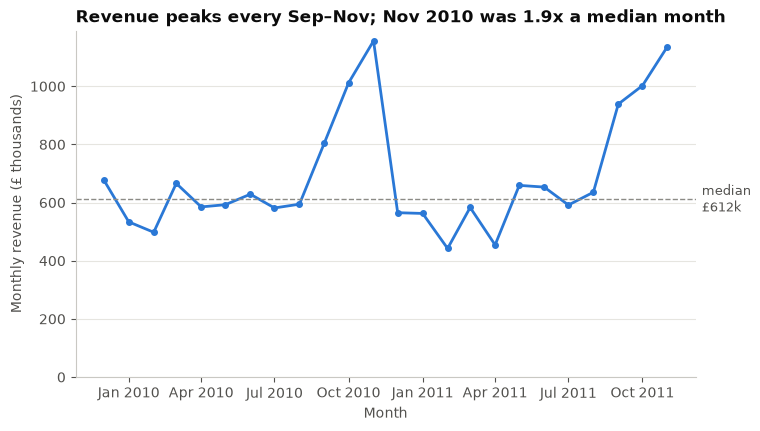

In [3]:
full = monthly[~monthly["is_partial"]]
median_month = full["revenue"].median()
peak = full.loc[full["revenue"].idxmax()]
peak_ratio = peak["revenue"] / median_month

fig, ax = plt.subplots()
ax.plot(full["month"], full["revenue"] / 1e3, color=BLUE, marker="o", markersize=4)
ax.axhline(median_month / 1e3, color=GRAY, linewidth=1, linestyle="--")
# Label the reference line in the right margin so the text never sits on the data
ax.text(1.01, median_month / 1e3, f"median\n£{median_month / 1e3:.0f}k", transform=ax.get_yaxis_transform(),
        va="center", ha="left", color=INK_2, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set_title(f"Revenue peaks every Sep–Nov; {peak['month']:%b %Y} was {peak_ratio:.1f}x a median month")
ax.set_ylabel("Monthly revenue (£ thousands)")
ax.set_xlabel("Month")
ax.set_ylim(bottom=0)
save(fig, "01_monthly_revenue.png")
plt.show()

## 2. Top 10 countries by revenue

In [4]:
countries_sql = '''
SELECT
    Country,
    round(sum(Revenue), 2)                                    AS revenue,
    count(DISTINCT "Customer ID")                             AS customers,
    round(100 * sum(Revenue) / sum(sum(Revenue)) OVER (), 2)  AS pct_of_total
FROM sales
GROUP BY Country
ORDER BY revenue DESC
LIMIT 10
'''
countries = duckdb.sql(countries_sql).df()
countries

,Country,revenue,customers,pct_of_total
0,United Kingdom,14288773.50,5334,83.71
1,EIRE,586626.08,3,3.44
2,Netherlands,549773.41,22,3.22
3,Germany,383289.00,107,2.25
4,France,309403.16,93,1.81
5,Australia,167800.01,15,0.98
6,Spain,97766.75,38,0.57
7,Switzerland,93400.94,22,0.55
8,Sweden,86045.14,19,0.50
9,Denmark,67422.69,12,0.40


## 3. Top 3 products per country (top 5 countries)

`ROW_NUMBER()` restarts at 1 for every country, so `WHERE rn <= 3` keeps each country's top three.
A stock code can have slightly different descriptions over time, so the most common one is shown.

In [5]:
top_products_sql = '''
WITH top_countries AS (
    SELECT Country
    FROM sales
    GROUP BY Country
    ORDER BY sum(Revenue) DESC
    LIMIT 5
),
product_revenue AS (
    SELECT
        s.Country,
        s.StockCode,
        mode(s.Description)  AS description,
        sum(s.Revenue)       AS revenue
    FROM sales s
    JOIN top_countries t USING (Country)
    GROUP BY s.Country, s.StockCode
),
ranked AS (
    SELECT
        *,
        ROW_NUMBER() OVER (PARTITION BY Country ORDER BY revenue DESC) AS rn
    FROM product_revenue
)
SELECT Country, rn AS rank, StockCode, description, round(revenue, 2) AS revenue
FROM ranked
WHERE rn <= 3
ORDER BY (SELECT sum(Revenue) FROM sales x WHERE x.Country = ranked.Country) DESC, rn
'''
top_products = duckdb.sql(top_products_sql).df()
top_products

,Country,rank,StockCode,description,revenue
0,United Kingdom,1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,227965.51
1,United Kingdom,2,22423,REGENCY CAKESTAND 3 TIER,225862.45
2,United Kingdom,3,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
3,EIRE,1,22423,REGENCY CAKESTAND 3 TIER,14636.85
4,EIRE,2,20914,SET/5 RED SPOTTY LID GLASS BOWLS,7710.10
5,EIRE,3,21843,RED RETROSPOT CAKE STAND,6075.15
6,Netherlands,1,22326,ROUND SNACK BOXES SET OF4 WOODLAND,13315.10
7,Netherlands,2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,10932.50
8,Netherlands,3,22630,DOLLY GIRL LUNCH BOX,10797.90
9,Germany,1,22423,REGENCY CAKESTAND 3 TIER,13548.90


## 4. Revenue concentration

Customers are ranked by lifetime revenue with `ROW_NUMBER()`. The top *k*% is the first `ceil(k/100 × n)` customers.
The same ranking drives the Lorenz-style curve: cumulative revenue share against customer percentile.

In [6]:
concentration_sql = '''
WITH customer_revenue AS (
    SELECT "Customer ID" AS customer_id, sum(Revenue) AS revenue
    FROM sales
    GROUP BY 1
),
ranked AS (
    SELECT
        revenue,
        ROW_NUMBER() OVER (ORDER BY revenue DESC) AS rn,
        count(*)     OVER ()                      AS n,
        sum(revenue) OVER ()                      AS total
    FROM customer_revenue
)
SELECT
    any_value(n)                                                                  AS customers,
    round(100 * sum(revenue) FILTER (WHERE rn <= ceil(0.01 * n)) / any_value(total), 2) AS top_1pct_share,
    round(100 * sum(revenue) FILTER (WHERE rn <= ceil(0.10 * n)) / any_value(total), 2) AS top_10pct_share,
    round(100 * sum(revenue) FILTER (WHERE rn <= ceil(0.20 * n)) / any_value(total), 2) AS top_20pct_share
FROM ranked
'''
concentration = duckdb.sql(concentration_sql).df()
concentration

,customers,top_1pct_share,top_10pct_share,top_20pct_share
0,5852,32.09,63.89,77.17


In [7]:
lorenz_sql = '''
WITH customer_revenue AS (
    SELECT "Customer ID" AS customer_id, sum(Revenue) AS revenue
    FROM sales
    GROUP BY 1
)
SELECT
    100.0 * ROW_NUMBER() OVER (ORDER BY revenue DESC) / count(*) OVER ()                   AS customer_pct,
    100.0 * sum(revenue) OVER (ORDER BY revenue DESC ROWS UNBOUNDED PRECEDING) / sum(revenue) OVER () AS cum_revenue_pct
FROM customer_revenue
ORDER BY customer_pct
'''
lorenz = duckdb.sql(lorenz_sql).df()
lorenz.iloc[[0, len(lorenz) // 100, len(lorenz) // 10, len(lorenz) // 5, -1]]

,customer_pct,cum_revenue_pct
0,0.017088,3.403839
58,1.008202,32.086688
585,10.013671,63.891455
1170,20.010253,77.167754
5851,100.000000,100.000000


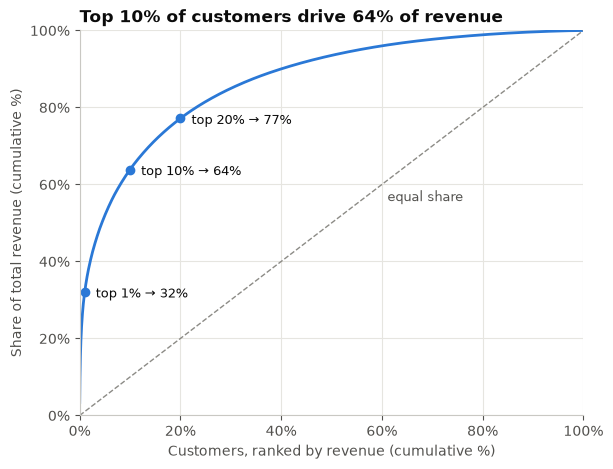

In [8]:
top10 = concentration.loc[0, "top_10pct_share"]

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.plot(lorenz["customer_pct"], lorenz["cum_revenue_pct"], color=BLUE)
ax.plot([0, 100], [0, 100], color=GRAY, linewidth=1, linestyle="--")
ax.annotate("equal share", (60, 60), xytext=(4, -12), textcoords="offset points", color=INK_2, fontsize=9)
for pct, col in [(1, "top_1pct_share"), (10, "top_10pct_share"), (20, "top_20pct_share")]:
    share = concentration.loc[0, col]
    ax.plot([pct], [share], "o", color=BLUE, markersize=6)
    ax.annotate(f"top {pct}% → {share:.0f}%", (pct, share), xytext=(8, -4), textcoords="offset points", fontsize=9)
ax.set_title(f"Top 10% of customers drive {top10:.0f}% of revenue")
ax.set_xlabel("Customers, ranked by revenue (cumulative %)")
ax.set_ylabel("Share of total revenue (cumulative %)")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.grid(axis="x")
save(fig, "02_revenue_concentration.png")
plt.show()

## 5. Average order value by month

In [9]:
aov_sql = '''
WITH orders AS (
    SELECT Invoice, date_trunc('month', min(InvoiceDate)) AS month, sum(Revenue) AS order_value
    FROM sales
    GROUP BY Invoice
)
SELECT
    month,
    count(*)                    AS orders,
    round(avg(order_value), 2)  AS avg_order_value,
    round(median(order_value), 2) AS median_order_value
FROM orders
GROUP BY month
ORDER BY month
'''
aov = duckdb.sql(aov_sql).df()
aov

,month,orders,avg_order_value,median_order_value
0,2009-12-01,1497,452.85,304.70
1,2010-01-01,959,556.53,309.09
2,2010-02-01,1093,455.57,296.94
3,2010-03-01,1509,441.33,302.52
4,2010-04-01,1315,444.96,314.20
5,2010-05-01,1365,434.24,299.81
6,2010-06-01,1479,425.16,294.02
7,2010-07-01,1362,426.94,294.91
8,2010-08-01,1276,465.96,304.87
9,2010-09-01,1659,485.56,308.40


The median order stays in a narrow band all year while order count roughly doubles in the autumn, so the seasonal
peak comes from **more orders**, not bigger ones. The mean sits well above the median because a few wholesale-sized
orders pull it up, which also makes the monthly mean noisier.

## 6. Month-over-month retention

For each month *m*: of the customers who bought in *m*, what share bought again in *m*+1?
December 2011 is cut off on the 9th, so November 2011 (whose "next month" is that partial month) and December 2011
itself are excluded. Including November would understate retention.

In [10]:
retention_sql = '''
WITH active AS (
    SELECT DISTINCT "Customer ID" AS customer_id, date_trunc('month', InvoiceDate) AS month
    FROM sales
),
next_month AS (
    SELECT
        a.month,
        count(*)            AS active_customers,
        count(b.customer_id) AS retained_next_month
    FROM active a
    LEFT JOIN active b
        ON b.customer_id = a.customer_id
       AND b.month = a.month + INTERVAL 1 MONTH
    -- stop two months before the end: the final month is partial
    WHERE a.month < (SELECT max(month) FROM active) - INTERVAL 1 MONTH
    GROUP BY a.month
)
SELECT *, round(100.0 * retained_next_month / active_customers, 2) AS retention_pct
FROM next_month
ORDER BY month
'''
retention = duckdb.sql(retention_sql).df()
retention

,month,active_customers,retained_next_month,retention_pct
0,2009-12-01,951,333,35.02
1,2010-01-01,701,261,37.23
2,2010-02-01,771,312,40.47
3,2010-03-01,1051,376,35.78
4,2010-04-01,939,343,36.53
5,2010-05-01,965,367,38.03
6,2010-06-01,1034,390,37.72
7,2010-07-01,924,350,37.88
8,2010-08-01,910,362,39.78
9,2010-09-01,1136,460,40.49


In [11]:
# Pooled rate: all retained customer-months / all active customer-months
pooled_retention = 100 * retention["retained_next_month"].sum() / retention["active_customers"].sum()
print(f"pooled month-over-month retention: {pooled_retention:.1f}%")
print(f"range: {retention['retention_pct'].min():.1f}% - {retention['retention_pct'].max():.1f}%")

pooled month-over-month retention: 38.6%
range: 30.9% - 45.3%


Only a little over a third of a month's buyers come back the next month, which is expected for a wholesaler with
lumpy ordering. That is why the churn definition later uses a 90-day window instead of one month.

## Record key numbers for RESULTS.md

In [12]:
save_metrics("02_sql", {
    "peak_month": f"{peak['month']:%Y-%m}",
    "peak_month_revenue_gbp": round(float(peak["revenue"]), 2),
    "median_month_revenue_gbp": round(float(median_month), 2),
    "peak_vs_median_ratio": round(float(peak_ratio), 2),
    "top_countries": countries[["Country", "revenue", "pct_of_total"]].to_dict(orient="records"),
    "uk_revenue_pct": float(countries.loc[countries["Country"] == "United Kingdom", "pct_of_total"].iloc[0]),
    "top_1pct_customers": math.ceil(0.01 * concentration.loc[0, "customers"]),
    "top_10pct_customers": math.ceil(0.10 * concentration.loc[0, "customers"]),
    "top_1pct_share": float(concentration.loc[0, "top_1pct_share"]),
    "top_10pct_share": float(concentration.loc[0, "top_10pct_share"]),
    "top_20pct_share": float(concentration.loc[0, "top_20pct_share"]),
    "median_order_value_min_gbp": float(aov["median_order_value"].min()),
    "median_order_value_max_gbp": float(aov["median_order_value"].max()),
    "aov_min_gbp": float(aov["avg_order_value"].min()),
    "aov_max_gbp": float(aov["avg_order_value"].max()),
    "pooled_mom_retention_pct": round(float(pooled_retention), 2),
    "mom_retention_min_pct": float(retention["retention_pct"].min()),
    "mom_retention_max_pct": float(retention["retention_pct"].max()),
})

saved metrics/02_sql.json (18 keys)
